In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Modelado y Evaluación
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv('/content/retail_sales_dataset.csv')

In [4]:
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [5]:
print(f"Dataset cargado con éxito. Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head()

Dataset cargado con éxito. Dimensiones: 1000 filas y 9 columnas.


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [6]:
print("--- Verificación de Valores Nulos ---")
print(df.isnull().sum(), "\n")

print("--- Verificación de Registros Duplicados ---")
duplicados = df.duplicated().sum()
print(f"Total de registros completamente duplicados: {duplicados}\n")

--- Verificación de Valores Nulos ---
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64 

--- Verificación de Registros Duplicados ---
Total de registros completamente duplicados: 0



In [7]:
# Si existieran duplicados, se eliminan con: df.drop_duplicates(inplace=True)

print("--- Tipos de Datos Iniciales ---")
print(df.dtypes)

--- Tipos de Datos Iniciales ---
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object


In [8]:
# Convertir la columna Date a tipo datetime
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
# Verificar consistencia en variables categóricas (limpieza de espacios y capitalización)
df['Gender'] = df['Gender'].str.strip().str.capitalize()
df['Product Category'] = df['Product Category'].str.strip().str.capitalize()

print("Categorías únicas en 'Gender':", df['Gender'].unique())
print("Categorías únicas en 'Product Category':", df['Product Category'].unique())

Categorías únicas en 'Gender': ['Male' 'Female']
Categorías únicas en 'Product Category': ['Beauty' 'Clothing' 'Electronics']


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [11]:
# Estadísticas para variables numéricas
print("--- Estadísticas Descriptivas Numéricas ---")
display(df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].describe())

--- Estadísticas Descriptivas Numéricas ---


,Age,Quantity,Price per Unit,Total Amount
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,41.39200,2.514000,179.890000,456.000000
std,13.68143,1.132734,189.681356,559.997632
min,18.00000,1.000000,25.000000,25.000000
25%,29.00000,1.000000,30.000000,60.000000
50%,42.00000,3.000000,50.000000,135.000000
75%,53.00000,4.000000,300.000000,900.000000
max,64.00000,4.000000,500.000000,2000.000000


In [12]:
# Estadísticas para variables categóricas
print("\n--- Estadísticas Descriptivas Categóricas ---")
display(df[['Gender', 'Product Category']].describe())


--- Estadísticas Descriptivas Categóricas ---


,Gender,Product Category
count,1000,1000
unique,2,3
top,Female,Clothing
freq,510,351


/tmp/ipykernel_5400/48655415.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Product Category', y='Total Amount', estimator=sum, ax=axes[0, 1], palette='viridis', errorbar=None)


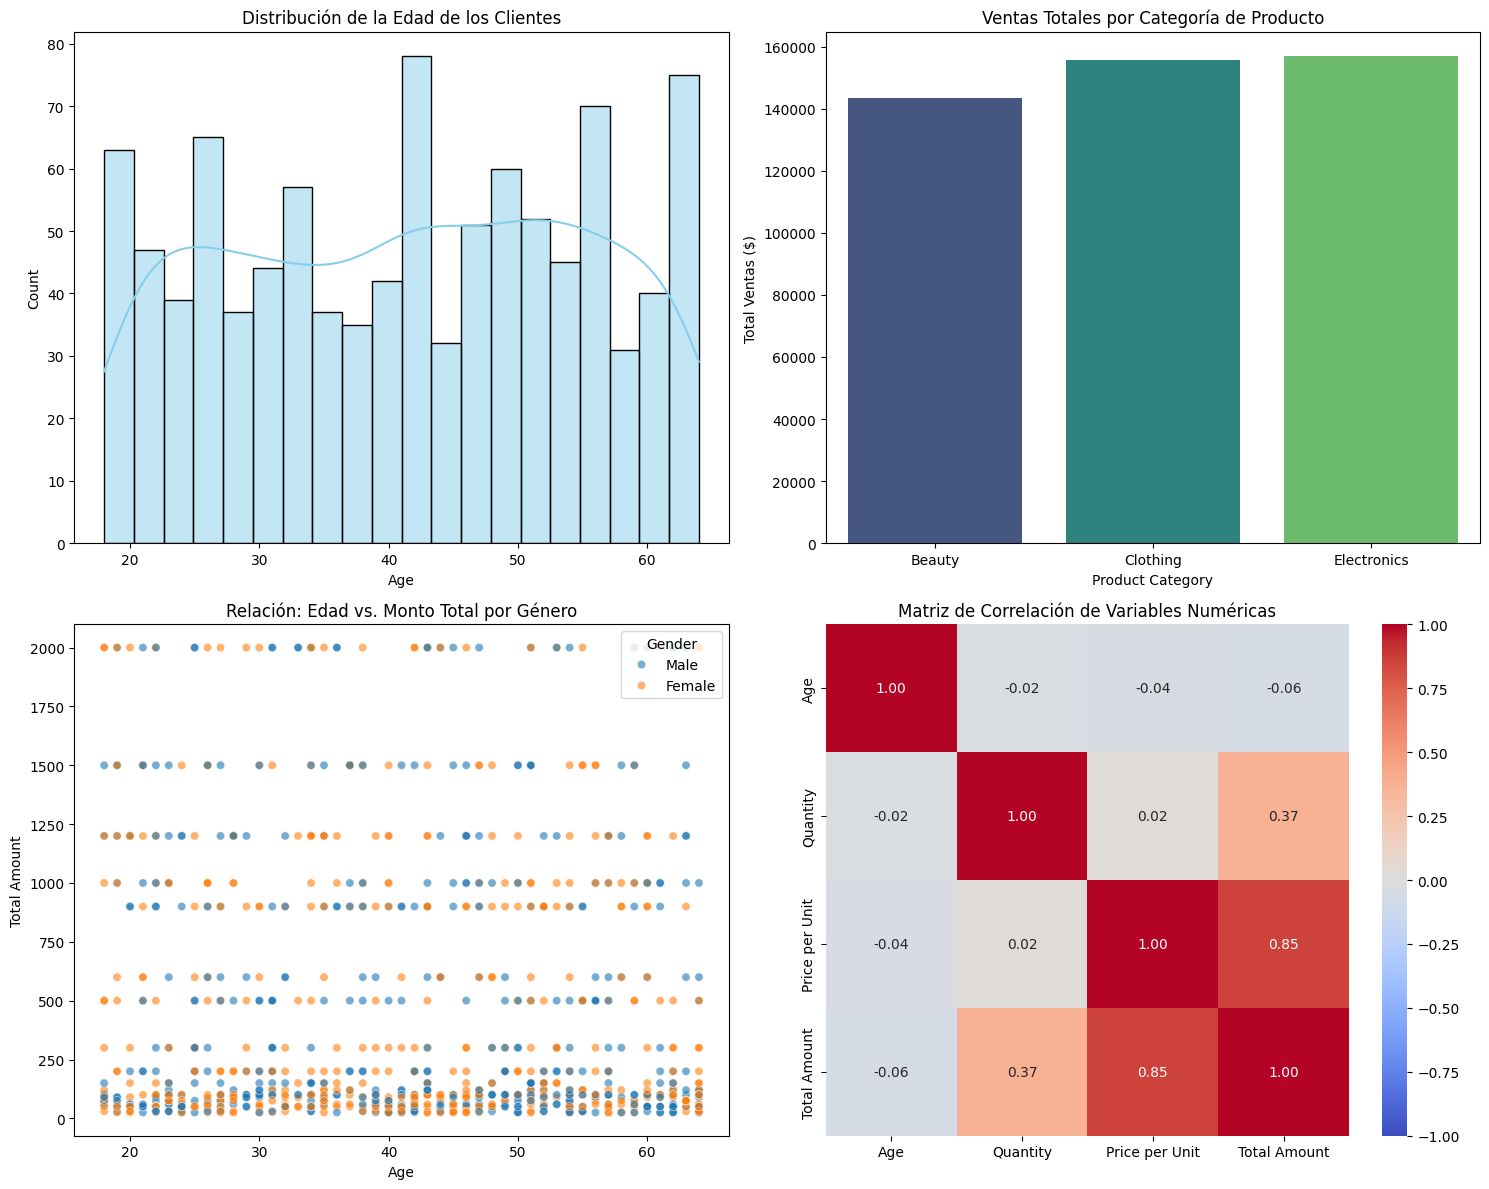

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Distribución de la Edad (Histograma)
sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribución de la Edad de los Clientes')

# 2. Ventas Totales por Categoría de Producto (Gráfico de Barras)
sns.barplot(data=df, x='Product Category', y='Total Amount', estimator=sum, ax=axes[0, 1], palette='viridis', errorbar=None)
axes[0, 1].set_title('Ventas Totales por Categoría de Producto')
axes[0, 1].set_ylabel('Total Ventas ($)')

# 3. Relación Edad vs Total Amount por Género (Dispersión)
sns.scatterplot(data=df, x='Age', y='Total Amount', hue='Gender', alpha=0.6, ax=axes[1, 0])
axes[1, 0].set_title('Relación: Edad vs. Monto Total por Género')

# 4. Matriz de Correlación (Mapa de Calor)
corr_matrix = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 1], vmin=-1, vmax=1)
axes[1, 1].set_title('Matriz de Correlación de Variables Numéricas')

plt.tight_layout()
plt.show()

In [15]:
# Clonamos el dataset para el modelo
df_model = df.copy()

In [16]:
# Variables predictoras irrelevantes para el comportamiento de compra directo
df_model.drop(columns=['Transaction ID', 'Customer ID', 'Date'], inplace=True)

# Codificación de variables categóricas (Gender y Product Category)
le_gender = LabelEncoder()
df_model['Gender'] = le_gender.fit_transform(df_model['Gender'])

le_category = LabelEncoder()
df_model['Product Category'] = le_category.fit_transform(df_model['Product Category'])

# Definir Características (X) y Objetivo (y)
# Intentaremos predecir 'Total Amount' basado en las características del cliente y del producto
X = df_model.drop(columns=['Total Amount'])
y = df_model['Total Amount']

# División en entrenamiento y prueba (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Conjunto de entrenamiento: {X_train.shape}")
print(f"Conjunto de prueba: {X_test.shape}")

Conjunto de entrenamiento: (800, 5)
Conjunto de prueba: (200, 5)


In [17]:
# Configuración del árbol de decisión
dt_reg = DecisionTreeRegressor(random_state=42)

param_grid_dt = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(estimator=dt_reg, param_grid=param_grid_dt, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_
print("Mejores Hiperparámetros para Decision Tree:", grid_dt.best_params_)

Mejores Hiperparámetros para Decision Tree: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [18]:
# Configuración del bosque aleatorio
rf_reg = RandomForestRegressor(random_state=42)

param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(estimator=rf_reg, param_grid=param_grid_rf, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
print("Mejores Hiperparámetros para Random Forest:", grid_rf.best_params_)


Mejores Hiperparámetros para Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}


In [19]:
# Predicciones
y_pred_dt = best_dt.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

In [20]:
# Funciones auxiliares de métricas
def calcular_metricas(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, r2

mse_dt, rmse_dt, r2_dt = calcular_metricas(y_test, y_pred_dt)
mse_rf, rmse_rf, r2_rf = calcular_metricas(y_test, y_pred_rf)

In [21]:
# Creación de tabla comparativa
resultados = pd.DataFrame({
    'Métrica': ['MSE', 'RMSE', 'R²'],
    'Decision Tree': [mse_dt, rmse_dt, r2_dt],
    'Random Forest': [mse_rf, rmse_rf, r2_rf]
})

display(resultados)

,Métrica,Decision Tree,Random Forest
0,MSE,0.0,0.0
1,RMSE,0.0,0.0
2,R²,1.0,1.0


In [24]:
## Análisis Comparativo de Rendimiento

#Nota sobre el comportamiento del Dataset:** Al analizar la estructura de los datos, la variable objetivo (`Total Amount`) es matemáticamente una relación directa y lineal exacta de la multiplicación entre `Quantity` y `Price per Unit` ($Total = Cantidad \times Precio$). Debido a esto, los modelos basados en árboles segmentan los datos de manera perfecta si se les da suficiente profundidad, obteniendo un $R^2$ cercano o igual a 1.0.
#Comparación:** El modelo de **Random Forest** tiende a ser más robusto frente a variaciones y previene el sobreajuste (overfitting) en datasets más complejos reduciendo la varianza a través del ensamble de múltiples árboles, superando al **Decision Tree** simple en condiciones de ruido o datos atípicos.

## Consideraciones Éticas y Tecnológicas

### Consideraciones Éticas
#Transparencia y Reproducibilidad:** El uso de una semilla fija (`random_state=42`) y la estructuración del pipeline con `GridSearchCV` garantiza que cualquier usuario o evaluador externo que ejecute este archivo obtendrá exactamente los mismos resultados numéricos e hiperparámetros óptimos.
#Imparcialidad y Sesgo:** Las variables sociodemográficas como el género (`Gender`) y la edad (`Age`) fueron analizadas para evitar sesgar decisiones automatizadas. En este modelo comercial, se observa que la distribución del gasto es equitativa entre géneros, mitigando el riesgo de discriminación algorítmica.

### Consideraciones Tecnológicas
#Herramientas:** Todo el ecosistema se implementó bajo estándares industriales (`pandas`, `scikit-learn`, `seaborn`).
#Escalabilidad:** Para datasets que superen millones de registros, se sugiere migrar el uso de `GridSearchCV` convencional hacia `RandomizedSearchCV` o frameworks de optimización bayesiana (como Optuna), y utilizar modelos optimizados de gradiente como XGBoost o LightGBM para mantener la eficiencia en el cómputo.